In [1]:
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

import os
import glob
from pathlib import Path
import torch
import torch.nn as nn
from Model.ResNet_18 import ResNet18
from Model.VGG16 import ModifiedVGG16
import torch.backends.cudnn as cudnn
import random
import numpy as np
from Dataset.CIFAR_10 import CIFAR10Dataset
from Dataset.CIFAR_100 import CIFAR100Dataset
from torch.utils.data import Subset, DataLoader
import torch.nn.utils.prune as prune
import time

In [2]:
def load_last_checkpoint(model_dir: Path):
    """
    Load the most recent .pth checkpoint in a model directory.
    Returns the checkpoint path or None if not found.
    """
    ckpt_files = sorted(model_dir.glob("*.pth"), key=os.path.getmtime)
    if not ckpt_files:
        return None
    last_ckpt = ckpt_files[-1]  # the newest one
    #print(f"[📦] Loading last checkpoint: {last_ckpt.name}")
    return last_ckpt

In [3]:
from Dataset.CIFAR_10 import CIFAR10Dataset
from Dataset.CIFAR_100 import CIFAR100Dataset

def create_train_subset(train_set, length, seed):
    n = len(train_set)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)

    idx_a, idx_b = perm[:length], perm[length:]

    ds_a = Subset(train_set, idx_a)
    ds_b = Subset(train_set, idx_b)

    # show sizes
    print(f"Created subsets: ds_a={len(ds_a)}, ds_b={len(ds_b)} (total={n})")

    return ds_a, ds_b

def sample_subset(dataset, sample_size, seed):
    """
    Randomly sample `sample_size` items from a given dataset.
    The selection is reproducible given the same seed.
    """
    n = len(dataset)
    rng = np.random.default_rng(seed)
    indices = rng.choice(n, size=sample_size, replace=False)
    print(len(indices))
    print(indices)
    return Subset(dataset, indices)

In [9]:
DATASET = ["CIFAR-100"]#"CIFAR-10"]  # , "MNIST", "CIFAR-100"
MODEL = ["VGG16"] #,

SEED = range(42, 52)
num_classes = 100
STRATEGY = ['FT-LL', 'FT-AL', 'RT-AL']
MODEL_DIR = Path("./saved_models/fine_tune_new")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

for seed in SEED:
    for strategy in STRATEGY:
    # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
        folder_name = f"CIFAR-100_VGG16_{seed}_{strategy}"
        model_folder = MODEL_DIR / folder_name
        
        if not model_folder.exists():
            print(f"[⚠️] Missing model folder: {model_folder}")
            continue
        
        # find last checkpoint
        ckpt_path = load_last_checkpoint(model_folder)
        if ckpt_path is None:
            print(f"[⚠️] No .pth files found in {model_folder}")
            continue
        print(ckpt_path)
        num_classes = 100 #if dataset == "CIFAR-10" else 100
        
        from Model.ResNet_18 import ResNet18
        
        #net = ResNet18(num_classes=num_classes).to(DEVICE)
        net = ModifiedVGG16(num_classes=num_classes).to(DEVICE)
        state = torch.load(ckpt_path, map_location=DEVICE)
        net.load_state_dict(state)
        
        dataset_100 = CIFAR100Dataset()
        in_eval_set = dataset_100.in_sample_set
        test_set = dataset_100.test_set
        train_subset1, train_subset2 = create_train_subset(in_eval_set, 40000, 42)
        train_mask = sample_subset(train_subset1, 40000, seed=42)
        trainloader = DataLoader(train_mask, batch_size=128, shuffle=False)

        eval_loader = DataLoader(test_set, batch_size=128, shuffle=False)
    
        layer_T_array, label_matrix = None, None
    
        net.eval()
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(eval_loader):
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = net(inputs)
        
                layer_T_array, label_matrix = calculate_MI_input_gpu(layer_T_array, label_matrix
                                                                ,outputs, targets, num_classes)
    
        #I_X_T, I_T_Y, time_gpu = MI_cal_gpu_v1(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
        #                      num_intervals=50)
    
        value_xt, value_ty, time_ref = MI_cal_v2(label_matrix.cpu().numpy(), layer_T_array.detach().cpu().numpy(), 10000)
    
        # --------- summary printout for this seed ---------
        '''diff_xt = abs(I_X_T - value_xt)
        diff_ty = abs(I_T_Y - value_ty)
        rel_xt = diff_xt / (abs(value_xt) + 1e-12)
        rel_ty = diff_ty / (abs(value_ty) + 1e-12)'''
    
        '''speedup_xt = time_ref / time_gpu if time_gpu > 0 else float('inf')'''
    
        print("\n" + "=" * 80)
        print(f"[Seed {seed}] MI consistency & speed report")
        '''print("-" * 80)
        print(f"I(X;T) GPU      : {I_X_T: .8f}")'''
        print(f"I(X;T) reference: {value_xt: .8f}")
        '''print(f" |Δ| abs        : {diff_xt: .3e}")
        print(f" |Δ| rel        : {rel_xt: .3e}")
        print("-" * 80)
        print(f"I(T;Y) GPU      : {I_T_Y: .8f}")'''
        print(f"I(T;Y) reference: {value_ty: .8f}")
        '''print(f" |Δ| abs        : {diff_ty: .3e}")
        print(f" |Δ| rel        : {rel_ty: .3e}")
        print("-" * 80)
        print(f"Time GPU        : {time_gpu: .4f} s")'''
        print(f"Time reference  : {time_ref: .4f} s")
        #print(f"Speedup (ref/GPU): {speedup_xt: .2f}x")
        print("=" * 80 + "\n")
    

    

saved_models\fine_tune_new\CIFAR-100_VGG16_42_FT-LL\epoch_29.pth
Created subsets: ds_a=40000, ds_b=10000 (total=50000)
40000
[33724 21985 18682 ... 26181 30957  3570]

[Seed 42] MI consistency & speed report
I(X;T) reference:  11.56737222
I(T;Y) reference:  6.39482322
Time reference  :  23.7275 s

saved_models\fine_tune_new\CIFAR-100_VGG16_42_FT-AL\epoch_59.pth
Created subsets: ds_a=40000, ds_b=10000 (total=50000)
40000
[33724 21985 18682 ... 26181 30957  3570]

[Seed 42] MI consistency & speed report
I(X;T) reference:  11.34659064
I(T;Y) reference:  6.40439497
Time reference  :  22.1373 s

saved_models\fine_tune_new\CIFAR-100_VGG16_42_RT-AL\epoch_79.pth
Created subsets: ds_a=40000, ds_b=10000 (total=50000)
40000
[33724 21985 18682 ... 26181 30957  3570]

[Seed 42] MI consistency & speed report
I(X;T) reference:  9.63845660
I(T;Y) reference:  6.04872321
Time reference  :  10.4186 s

[⚠️] Missing model folder: saved_models\fine_tune_new\CIFAR-100_VGG16_43_FT-LL
[⚠️] Missing model folder

In [23]:
DATASET = ["CIFAR-100"]#"CIFAR-10"]  # , "MNIST", "CIFAR-100"
MODEL = ["ResNet-18"] #,
SEED = range(42, 52)
num_classes = 100

MODEL_DIR = Path("./saved_models/normal_new")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

for seed in SEED:
    # each run is saved in its own folder, e.g. ./saved_models/CIFAR-10_ResNet-18_45/
    folder_name = f"CIFAR-100_ResNet-18_{seed}"
    model_folder = MODEL_DIR / folder_name
    
    if not model_folder.exists():
        print(f"[⚠️] Missing model folder: {model_folder}")
        continue
    
    # find last checkpoint
    ckpt_path = load_last_checkpoint(model_folder)
    if ckpt_path is None:
        print(f"[⚠️] No .pth files found in {model_folder}")
        continue
    
    num_classes = 10 if dataset == "CIFAR-10" else 100
    
    from Model.ResNet_18 import ResNet18
    
    net = ResNet18(num_classes=num_classes).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    net.load_state_dict(state)
    
    dataset_100 = CIFAR100Dataset()
    in_eval_set = dataset_100.in_sample_set
    train_subset1, train_subset2 = create_train_subset(in_eval_set, 40000, 42)
    train_mask = sample_subset(train_subset1, 40000, seed=42)
    trainloader = DataLoader(train_mask, batch_size=128, shuffle=False)

    layer_T_array, label_matrix = None, None

    net.eval()
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = net(inputs)
    
            layer_T_array, label_matrix = calculate_MI_input_gpu(layer_T_array, label_matrix
                                                            ,outputs, targets, num_classes)

    I_X_T, I_T_Y, time_gpu = MI_cal_gpu_v1(layer_T_array.to(device=DEVICE, dtype=torch.float32), label_matrix.to(device=DEVICE, dtype=torch.float32),
                          num_intervals=50)

    value_xt, value_ty, time_ref = MI_cal_v2(label_matrix.cpu().numpy(), layer_T_array.detach().cpu().numpy(), 40000)

    # --------- summary printout for this seed ---------
    diff_xt = abs(I_X_T - value_xt)
    diff_ty = abs(I_T_Y - value_ty)
    rel_xt = diff_xt / (abs(value_xt) + 1e-12)
    rel_ty = diff_ty / (abs(value_ty) + 1e-12)

    speedup_xt = time_ref / time_gpu if time_gpu > 0 else float('inf')

    print("\n" + "=" * 80)
    print(f"[Seed {seed}] MI consistency & speed report")
    print("-" * 80)
    print(f"I(X;T) GPU      : {I_X_T: .8f}")
    print(f"I(X;T) reference: {value_xt: .8f}")
    print(f" |Δ| abs        : {diff_xt: .3e}")
    print(f" |Δ| rel        : {rel_xt: .3e}")
    print("-" * 80)
    print(f"I(T;Y) GPU      : {I_T_Y: .8f}")
    print(f"I(T;Y) reference: {value_ty: .8f}")
    print(f" |Δ| abs        : {diff_ty: .3e}")
    print(f" |Δ| rel        : {rel_ty: .3e}")
    print("-" * 80)
    print(f"Time GPU        : {time_gpu: .4f} s")
    print(f"Time reference  : {time_ref: .4f} s")
    print(f"Speedup (ref/GPU): {speedup_xt: .2f}x")
    print("=" * 80 + "\n")
    

    

Created subsets: ds_a=40000, ds_b=10000 (total=50000)
40000
[33724 21985 18682 ... 26181 30957  3570]

[Seed 42] MI consistency & speed report
--------------------------------------------------------------------------------
I(X;T) GPU      :  6.90852785
I(X;T) reference:  6.90852787
 |Δ| abs        :  2.085e-08
 |Δ| rel        :  3.018e-09
--------------------------------------------------------------------------------
I(T;Y) GPU      :  6.62277412
I(T;Y) reference:  6.62277404
 |Δ| abs        :  8.722e-08
 |Δ| rel        :  1.317e-08
--------------------------------------------------------------------------------
Time GPU        :  12.1643 s
Time reference  :  7.5205 s
Speedup (ref/GPU):  0.62x

Created subsets: ds_a=40000, ds_b=10000 (total=50000)
40000
[33724 21985 18682 ... 26181 30957  3570]

[Seed 43] MI consistency & speed report
--------------------------------------------------------------------------------
I(X;T) GPU      :  7.92670441
I(X;T) reference:  7.92670464
 |Δ| abs  

In [5]:
import torch.nn.functional as F
# collect layer_T_array for MI analysis
def calculate_MI_input_gpu(layer_T_array, label_matrix, outputs, targets, num_classes):
    outputs_detached = outputs.detach() # [batch, D]
    targets_detached = targets.detach() # [batch]


    # accumulate logits (layer_T_array)
    if layer_T_array is None:
        layer_T_array = outputs_detached
    else:
        layer_T_array = torch.cat((layer_T_array, outputs_detached), dim=0)

    # accumulate one-hot labels on the same device
    batch_onehot = F.one_hot(targets_detached, num_classes=num_classes).float()  # stays on GPU

    if label_matrix is None:
        label_matrix = batch_onehot
    else:
        label_matrix = torch.cat((label_matrix, batch_onehot), dim=0)
    
    return layer_T_array, label_matrix

In [6]:
def MI_formula_cal(matrix, p1, p2): #p1, p2 represents marginals
    mask = matrix > 0

    denom = p1[:, None] * p2[None, :]
    
    ratio = matrix / denom
    
    log_ratio = torch.log2(ratio)
    
    MI = (matrix * log_ratio)[mask].sum()

    return MI

def find_match_indices(layer_T, non_repeat, i):
    # layer_T: [N, C]
    # non_repeat: python list of indices
    # returns: mask [len(non_repeat)] of equality with layer_T[i]

    nr_idx = torch.tensor(non_repeat, device=layer_T.device, dtype=torch.long)
    # Compare layer_T[i] to all non_repeat rows at once
    eq = (layer_T[i].unsqueeze(0) == layer_T[nr_idx])   # [len(nonrepeat), C]
    return eq.all(dim=1)  # boolean vector length = len(nonrepeat)
    
import time
def MI_cal_gpu_v1(layer_T, label_matrix, num_intervals=50):
    start_time = time.time()
    device = layer_T.device
    layer_T = torch.softmax(layer_T, dim=1)

    bins = torch.linspace(0, 1, num_intervals + 1, device=device, dtype=torch.float32)
    layer_T_discrete = torch.bucketize(layer_T, bins, right=True) - 1
    layer_T_discrete = layer_T_discrete.clamp(0, num_intervals - 1)

    layer_T = layer_T_discrete.contiguous()
    N, C = layer_T.shape

    XT_matrix = torch.zeros((N, N), device=device, dtype=torch.float32)
    non_repeat, mark_list = [], []

    for i in range(N):
        pre_mark_size = len(mark_list)
    
        if i == 0:
            # First row always unique
            non_repeat.append(i)
            mark_list.append(i)
            XT_matrix[i, i] = 1
            continue
    
        matches = find_match_indices(layer_T, non_repeat, i)
    
        if matches.any():
            j = matches.nonzero()[0].item()  # First matched index in non_repeat
            match_idx = non_repeat[j]
            mark_list.append(match_idx)
            XT_matrix[i, match_idx] = 1
        else:
            # No match found → new unique pattern
            new_idx = non_repeat[-1] + 1
            non_repeat.append(new_idx)
            mark_list.append(new_idx)
            XT_matrix[i, new_idx] = 1

    N_unique = len(non_repeat)
    XT_matrix = XT_matrix[:, :N_unique]
    XT_matrix = XT_matrix / N

    P_X_for_layer_T = XT_matrix.sum(dim=1)
    P_layer_T_for_X = XT_matrix.sum(dim=0)

    I_X_T = MI_formula_cal(XT_matrix, P_X_for_layer_T, P_layer_T_for_X)

    mark_t = torch.tensor(mark_list, device=device, dtype=torch.long)
    K = len(non_repeat)
    
    TY_matrix = torch.zeros((K, label_matrix.shape[1]), 
                            device=device, dtype=torch.float32)
    
    TY_matrix.index_add_(0, mark_t, label_matrix)
    
    TY_matrix = TY_matrix / N

    P_layer_T_for_Y = TY_matrix.sum(dim=1)
    P_Y_for_layer_T = TY_matrix.sum(dim=0)

    I_T_Y = MI_formula_cal(TY_matrix, P_layer_T_for_Y, P_Y_for_layer_T)

    end_time = time.time()
    elapsed_time = end_time - start_time

    return I_X_T.item(), I_T_Y.item(), elapsed_time

In [7]:
NUM_INTERVALS=50
import pandas as pd
def MI_cal_v2(label_matrix, layer_T, NUM_TEST_MASK):
    start_time = time.time()
    NUM_LABEL = label_matrix.shape[1]

    MI_XT=0
    MI_TY=0
    # This part is to transfrom logits to probabilities through softmax.
    layer_T = np.exp(layer_T - np.max(layer_T,axis=1,keepdims=True)) #numerical stabilization: prevent potential overflow issues for exponentiation.
    layer_T /= np.sum( layer_T,axis=1,keepdims=True)
    
    layer_T = Discretize_v2(layer_T)
    XT_matrix = np.zeros((NUM_TEST_MASK,NUM_TEST_MASK)) # 1000*1000
    Non_repeat=[]
    mark_list=[]
    for i in range(NUM_TEST_MASK):
        pre_mark_size = len(mark_list)
        if i==0:
            Non_repeat.append(i)
            mark_list.append(i)
            XT_matrix[i,i]=1
        else:
            for j in range(len(Non_repeat)):
                if (layer_T[i] ==layer_T[ Non_repeat[j] ]).all():
                    mark_list.append(Non_repeat[j])
                    XT_matrix[i,Non_repeat[j]]=1
                    break
        if pre_mark_size == len(mark_list):
            Non_repeat.append(Non_repeat[-1]+1)
            mark_list.append(Non_repeat[-1])
            XT_matrix[i,Non_repeat[-1]]=1
    
    XT_matrix = np.delete(XT_matrix,range(len(Non_repeat),NUM_TEST_MASK),axis=1)				
    XT_matrix = XT_matrix/NUM_TEST_MASK
    P_X_for_layer_T = np.sum(XT_matrix,axis=1)
    P_layer_T_for_X= np.sum(XT_matrix,axis=0)
    for i in range(XT_matrix.shape[0]):
        for j in range(XT_matrix.shape[1]):
            if XT_matrix[i,j]==0:
                pass
            else:
                MI_XT+=XT_matrix[i,j]*np.log2(XT_matrix[i,j]/
                                              (P_X_for_layer_T[i]*P_layer_T_for_X[j]))

    TY_matrix = np.zeros((len(Non_repeat),NUM_LABEL))
    mark_list = np.array(mark_list)
    for i in range(len(Non_repeat)):
        TY_matrix[i,:] = np.sum(label_matrix[  np.where(mark_list==i)[0]  , : ] ,axis=0 )
    TY_matrix = TY_matrix/NUM_TEST_MASK
    P_layer_T_for_Y = np.sum(TY_matrix,axis=1)
    P_Y_for_layer_T = np.sum(TY_matrix,axis=0)
    for i in range(TY_matrix.shape[0]):
        for j in range(TY_matrix.shape[1]):
            if TY_matrix[i,j]==0:
                pass
            else:
                MI_TY+=TY_matrix[i,j]*np.log2(TY_matrix[i,j]/(P_layer_T_for_Y[i]*P_Y_for_layer_T[j]))

    end_time = time.time()
    elapsed_time = end_time - start_time
    
    return MI_XT,MI_TY, elapsed_time



#将连续数据转换为离散数据
def Discretize_v2(layer_T):	
    labels = np.arange(NUM_INTERVALS) # [0, 1, 2, 3 ..., 49]
    bins = np.arange(NUM_INTERVALS+1) # [0, 1, 2, 3 ..., 49, 50]
    bins = bins/float(NUM_INTERVALS)  # [0, 0.02, 0.04, ..., 1.0]
    
    for i in range(layer_T.shape[1]):
        temp = pd.cut(layer_T[:,i],bins,labels=labels)
        layer_T[:,i] = np.array(temp)
    return layer_T

In [13]:
import os
import glob
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # needed for full CUDA determinism
from pathlib import Path
import random
import numpy as np
import torch
import torch.backends.cudnn as cudnn
import os
import csv
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import torchvision
import torchvision.transforms as transforms

In [ ]:
def seed_worker(worker_id):
    # Worker gets a different, but deterministic, seed derived from the main seed
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # all GPUs

    if deterministic:
        cudnn.deterministic = True
        cudnn.benchmark = False
        # Raises error if a non-deterministic op is used; great for debugging reproducibility
        torch.use_deterministic_algorithms(True)
    else:
        cudnn.deterministic = False
        cudnn.benchmark = True

In [15]:
ckpt_path

WindowsPath('saved_models/normal/CIFAR-100_VGG16_51/epoch_199.pth')

In [ ]:
dataset_100 = CIFAR100Dataset()
in_eval_set = dataset_100.in_sample_set
train_subset1, train_subset2 = create_train_subset(in_eval_set, 40000, 42)
train_mask = sample_subset(train_subset1, 40000, seed=42)
trainloader = DataLoader(train_mask, batch_size=128, shuffle=False)

In [1]:
import torch.nn as nn

m = nn.BatchNorm2d(64)
print(m.training)  # True

m.eval()
print(m.training)  # False

net = nn.Sequential(m)
net.train()
print(m.training)  # Still False → eval mode persists


True
False
True


In [2]:
import os
from dataclasses import dataclass
from typing import Callable, List, Optional, Dict, Any, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Utilities
# -----------------------------
def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")


def read_mi_point(csv_path: str, domain: str) -> Tuple[float, float]:
    """
    Read a single MI coordinate (ix, iy) from a CSV file.
    Assumes the MI values are stored in the first row.
    """
    df = pd.read_csv(csv_path)

    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In"])
        iy_col = find_column(df, ["I(T;Y)-In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out"])
        iy_col = find_column(df, ["I(T;Y)-Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    ix = float(df[ix_col].iloc[0])
    iy = float(df[iy_col].iloc[0])
    return ix, iy


# -----------------------------
# Group specification
# -----------------------------
@dataclass
class GroupSpec:
    """
    Defines how to plot one "group" of points.

    - csv_paths: list of files for that group
    - label: legend label for this group
    - style: scatter style kwargs (marker, color, s, alpha, etc.)
    - annotate: whether to annotate each point
    - annotate_text_fn: function that produces text from csv_path (and optionally ix, iy)
    """
    label: str
    csv_paths: List[str]
    style: Dict[str, Any]

    domain:str = "in"

    annotate: bool = False
    annotate_text_fn: Optional[Callable[[str], str]] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None  # e.g., xytext, fontsize


# -----------------------------
# Anchor specification
# -----------------------------
@dataclass
class AnchorSpec:
    """
    Defines how to pick and plot an anchor point from one GroupSpec.

    - group_label: which group to search in (by GroupSpec.label)
    - select_fn: function that selects an anchor index given list of points
    - style: scatter style override for the anchor point
    - annotate_text: optional anchor annotation
    """
    group_label: str
    select_fn: Callable[[List[Dict[str, Any]]], int]
    style: Dict[str, Any]
    annotate_text: Optional[str] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None


# -----------------------------
# Core plotting function
# -----------------------------
def plot_information_plane(
    groups: List[GroupSpec],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (7, 6),
    grid: bool = True,
    plain_ticks: bool = True,
    anchor: Optional[AnchorSpec] = None,
):
    """
    Modular MI plane plotter. Plots any number of groups, each defined by GroupSpec.

    Args:
        groups: list of GroupSpec
        domain: "in" or "out"
        title: plot title
        figsize: figure size
        anchor: optional AnchorSpec to highlight one anchor point
    """
    # assert domain in ["in", "out"]

    # Load all points for all groups (so anchor selection can be done cleanly)
    all_group_points: Dict[str, List[Dict[str, Any]]] = {}

    for g in groups:
        pts = []
        for p in g.csv_paths:
            ix, iy = read_mi_point(p, g.domain)
            pts.append({"path": p, "ix": ix, "iy": iy})
        all_group_points[g.label] = pts

    # Determine anchor index if requested
    anchor_idx = None
    if anchor is not None:
        if anchor.group_label not in all_group_points:
            raise ValueError(
                f"AnchorSpec.group_label='{anchor.group_label}' not found in groups."
            )
        anchor_idx = anchor.select_fn(all_group_points[anchor.group_label])

    # Plot
    plt.figure(figsize=figsize)
    legend_seen = set()

    for g in groups:
        pts = all_group_points[g.label]
        for i, pt in enumerate(pts):
            is_anchor = (
                anchor is not None
                and g.label == anchor.group_label
                and anchor_idx is not None
                and i == anchor_idx
            )

            # Scatter style
            style = dict(g.style)  # copy
            label = None

            if is_anchor:
                # Override with anchor style
                style.update(anchor.style)
                label = anchor.style.get("label", None)
                if label is None:
                    label = "Anchor"
            else:
                label = g.label

            # Deduplicate legend entries
            if label in legend_seen:
                label_for_scatter = None
            else:
                label_for_scatter = label
                legend_seen.add(label)

            plt.scatter(pt["ix"], pt["iy"], label=label_for_scatter, **style)

            # Annotation
            if is_anchor and anchor.annotate_text:
                akw = anchor.annotate_kwargs or {"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
                plt.annotate(
                    anchor.annotate_text,
                    (pt["ix"], pt["iy"]),
                    textcoords="offset points",
                    **akw
                )
            elif g.annotate and g.annotate_text_fn is not None:
                text = g.annotate_text_fn(pt["path"])
                akw = g.annotate_kwargs or {"xytext": (6, 6), "fontsize": 9}
                plt.annotate(
                    text,
                    (pt["ix"], pt["iy"]),
                    textcoords="offset points",
                    **akw
                )

    # Formatting
    plt.xlabel("I(X;T)")
    plt.ylabel("I(T;Y)")
    plt.title(title)

    if grid:
        plt.grid(True)

    if plain_ticks:
        ax = plt.gca()
        ax.ticklabel_format(style="plain", axis="x", useOffset=False)
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)

    plt.legend()
    plt.tight_layout()
    plt.show()


def parse_neg_overlapping_rate(path: str) -> str:
    # ..._<rate>_MI.csv (rate is second-to-last token)
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    return f"{float(tokens[-2]):.1f}"

def parse_neg_super_samples(path: str) -> str:
    # ..._<rate>_MI.csv (rate is second-to-last token)
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    return tokens[-2]

def parse_ft_seed_or_strategy(path: str) -> str:
    # example: ..._1.0_FT-AL_42_MI.csv  -> annotate "s42"
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    # tokens[-1] == "MI"
    ft_seed = tokens[-2]
    return f"s{ft_seed}"

def select_anchor_by_rate_1p0(points: List[Dict[str, Any]]) -> int:
    # choose the first point whose filename rate == 1.0; if multiple, pick max I(T;Y)
    candidates = []
    for i, pt in enumerate(points):
        r = float(os.path.basename(pt["path"]).replace(".csv", "").split("_")[-2])
        if abs(r - 1.0) < 1e-9:
            candidates.append(i)
    if not candidates:
        raise ValueError("No negative point found with rate=1.0 for anchor selection.")
    # choose highest iy (and if tie, smallest ix)
    return max(candidates, key=lambda i: (points[i]["iy"], -points[i]["ix"]))



In [2]:
import numpy as np
def generate_csv_paths(file_dir, dataset, model, victim_seed, rate_ls):
    csv_ls = []
    for rate in rate_ls:
        csv_name = f"training_log_{dataset}_{model}_{victim_seed}_{rate}_MI.csv"
        csv_ls.append(file_dir + csv_name)

    return csv_ls

DATASET = ["CIFAR-10"]
MODEL = ["ResNet-18","VGG16"]
VICTIM_SEED = range(42, 43)

OVERLAPPING = np.linspace(0,1,11)
SUPER = range(5000, 25001, 5000)

neg_group_dict = {}
for d in DATASET:
    for m in MODEL:
        for s in VICTIM_SEED:
            neg_group1 = generate_csv_paths("./saved_logs/normal_nega/MI/", d, m, s, OVERLAPPING)
        neg_group_dict[m] = neg_group1

In [9]:
neg_in_group1 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.0_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.1_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.2_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.30000000000000004_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.4_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.5_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.6000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.7000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.8_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.9_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv']

neg_out_group1 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv']

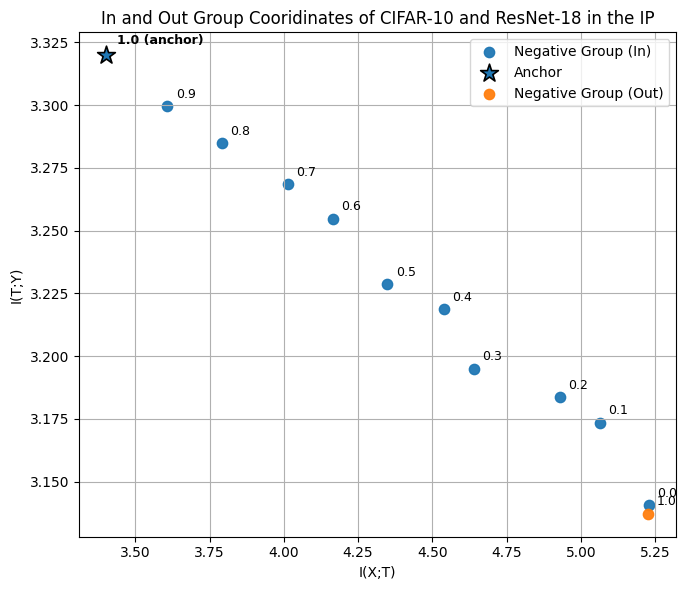

In [10]:
neg18_in_group_spec = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_in_group1,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg18_out_group_spec = GroupSpec(
    label="Negative Group (Out)",
    csv_paths=neg_out_group1,
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

plot_information_plane(
    groups=[neg18_in_group_spec, neg18_out_group_spec],
    title="In and Out Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=anchor_spec
)

In [11]:
neg_in_group1 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.0_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.1_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.2_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.30000000000000004_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.4_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.5_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.6000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.7000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.8_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.9_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_1.0_MI.csv']

neg_out_group1 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_1.0_MI.csv']

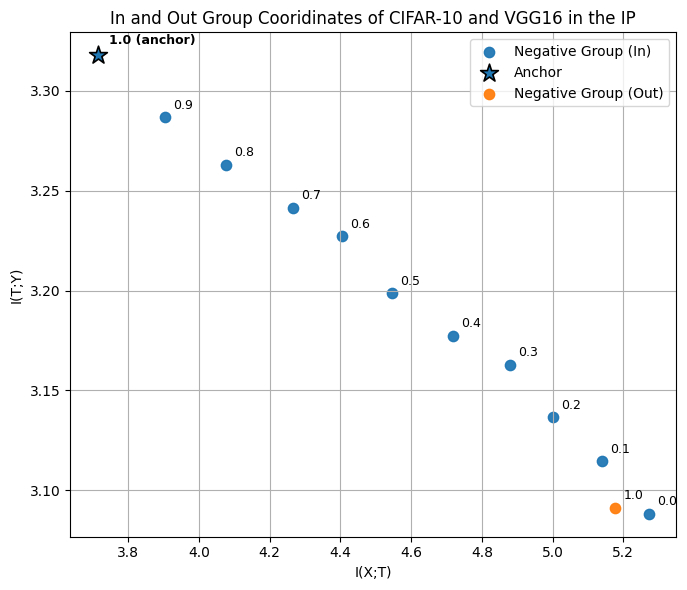

In [12]:
neg18_in_group_spec = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_in_group1,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg18_out_group_spec = GroupSpec(
    label="Negative Group (Out)",
    csv_paths=neg_out_group1,
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

plot_information_plane(
    groups=[neg18_in_group_spec, neg18_out_group_spec],
    title="In and Out Group Cooridinates of CIFAR-10 and VGG16 in the IP",
    anchor=anchor_spec
)

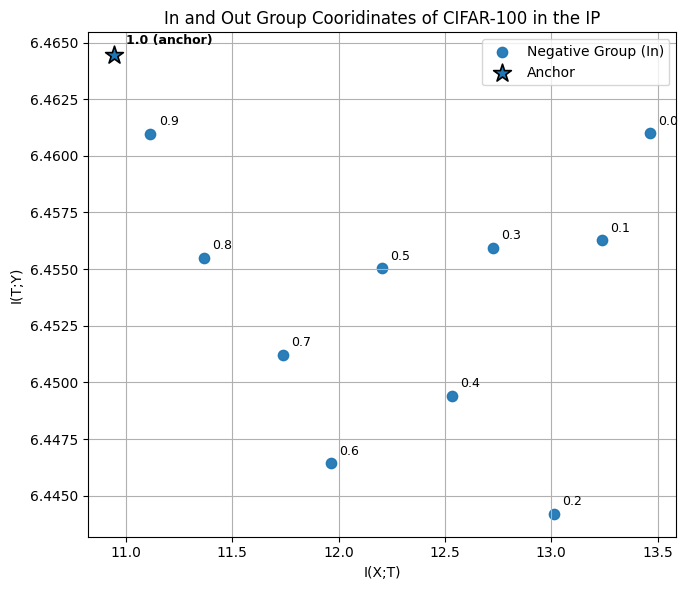

In [9]:
neg_in_group_100 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.0_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.1_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.2_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.30000000000000004_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.4_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.5_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.6000000000000001_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.7000000000000001_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.8_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.9_Mix_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_1.0_Mix_MI.csv']

neg18_in_group_spec_100 = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_in_group_100,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

plot_information_plane(
    groups=[neg18_in_group_spec_100],
    title="In and Out Group Cooridinates of CIFAR-100 in the IP",
    anchor=anchor_spec
)

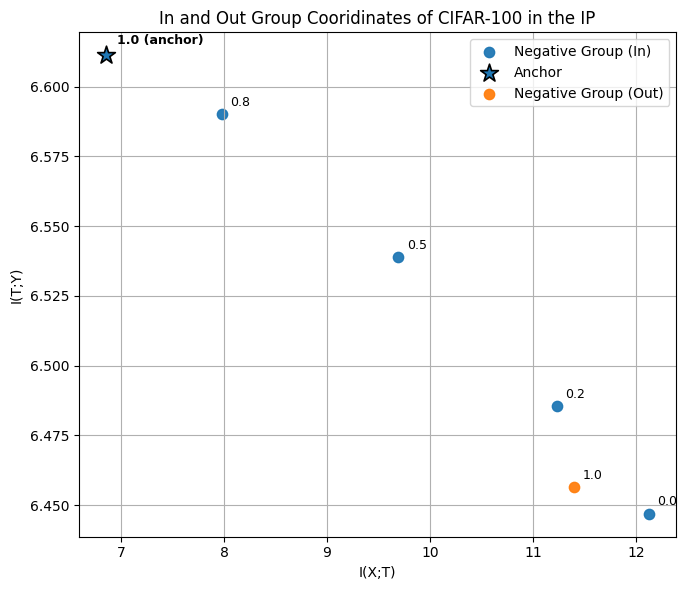

In [24]:
neg_in_group_100 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.0_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.2_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.5_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_0.8_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_1.0_MI.csv']

neg_out_group_100 = ['./saved_logs/normal_nega/MI/training_log_CIFAR-100_ResNet-18_42_1.0_MI.csv']

neg18_in_group_spec_100 = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_in_group_100,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg18_out_group_spec_100 = GroupSpec(
    label="Negative Group (Out)",
    csv_paths=neg_out_group_100,
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

plot_information_plane(
    groups=[neg18_in_group_spec_100, neg18_out_group_spec_100],
    title="In and Out Group Cooridinates of CIFAR-100 in the IP",
    anchor=anchor_spec
)

In [10]:
from collections import Counter
from typing import Any, Dict, Optional, Tuple, Union

import numpy as np
import torch
from torch.utils.data import Subset


def label_distribution(
    ds: Union[Subset, Any],
    num_classes: Optional[int] = None,
    use_targets_if_available: bool = True,
) -> Dict[str, Any]:
    """
    Compute label distribution for a torch Dataset or torch.utils.data.Subset.

    Returns a dict with:
      - counts: Counter {label: count}
      - total: total samples
      - num_classes: inferred or provided
      - histogram: np.ndarray of shape [num_classes] (if num_classes known)
      - proportions: np.ndarray of shape [num_classes] (if num_classes known)

    Notes:
      - For torchvision CIFAR datasets, prefers dataset.targets for speed.
      - Falls back to calling __getitem__ to read labels.
    """
    # Resolve base dataset + indices if Subset
    if isinstance(ds, Subset):
        base = ds.dataset
        indices = ds.indices
    else:
        base = ds
        indices = None

    # Fast path: use base.targets if available and requested
    labels_list = None
    if use_targets_if_available and hasattr(base, "targets"):
        targets = base.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().tolist()
        elif isinstance(targets, np.ndarray):
            targets = targets.tolist()

        if indices is None:
            labels_list = list(map(int, targets))
        else:
            labels_list = [int(targets[i]) for i in indices]

    # Fallback: index into dataset / subset and read y from returned sample
    if labels_list is None:
        if indices is None:
            # full dataset
            labels_list = []
            for i in range(len(base)):
                sample = base[i]
                y = sample[1]  # works for (x,y), (x,y,idx), (x,y,idx,...) ...
                labels_list.append(int(y) if not torch.is_tensor(y) else int(y.item()))
        else:
            labels_list = []
            for i in indices:
                sample = base[i]
                y = sample[1]
                labels_list.append(int(y) if not torch.is_tensor(y) else int(y.item()))

    counts = Counter(labels_list)
    total = len(labels_list)

    # infer num_classes if not provided
    if num_classes is None and total > 0:
        num_classes = max(counts.keys()) + 1

    out: Dict[str, Any] = {
        "counts": counts,
        "total": total,
        "num_classes": num_classes,
    }

    if num_classes is not None:
        hist = np.zeros(num_classes, dtype=np.int64)
        for k, v in counts.items():
            if 0 <= k < num_classes:
                hist[k] = v
        out["histogram"] = hist
        out["proportions"] = hist / max(total, 1)

        # quick balance diagnostics
        nonzero = hist[hist > 0]
        out["min_count_nonzero"] = int(nonzero.min()) if nonzero.size else 0
        out["max_count"] = int(hist.max()) if hist.size else 0
        out["num_missing_classes"] = int((hist == 0).sum())

    return out


In [ ]:
from util import *
train_set = CIFAR100Dataset().train_set
train_subset = prepare_group_subset(train_set, 0.0, f"./Indices/CIFAR-100")

dist = label_distribution(train_subset, num_classes=100)

print("Total:", dist["total"])
print("Missing classes:", dist["num_missing_classes"])
print("Min(nonzero):", dist["min_count_nonzero"], "Max:", dist["max_count"])

# Print per-class counts (sorted by class id)
for c in range(dist["num_classes"]):
    print(c, dist["histogram"][c])

In [5]:
from util import *
train_set = CIFAR100Dataset().train_set

num_classes = 100
group_A = create_or_load_group_A(dataset=train_set, save_dir='./Indices/CIFAR-100/',
                                              group_size=40000, num_classes=num_classes, seed=42, force_rebuild=False)

[INFO] Loading Group A from Indices\CIFAR-100\group_A_40000_seed42.npy


In [7]:
len(group_A)

40000

In [17]:
import filecmp

file1 = './Indices/CIFAR-100/group_A_seed42.npy'
file2 = './Indices/CIFAR-100/group_B_overlap_0.0.npy'

import numpy as np

A = np.load(file1)
B = np.load(file2)

print("Same length:", len(A) == len(B))
print("Same set:", set(A.tolist()) == set(B.tolist()))

A_sorted = np.sort(A)
B_sorted = np.sort(B)
print("Same sorted array:", np.array_equal(A_sorted, B_sorted))

# Useful diagnostics if not equal:
print("A only:", len(set(A.tolist()) - set(B.tolist())))
print("B only:", len(set(B.tolist()) - set(A.tolist())))
print("A duplicates:", len(A) - len(set(A.tolist())))
print("B duplicates:", len(B) - len(set(B.tolist())))



Same length: True
Same set: False
Same sorted array: False
A only: 25000
B only: 25000
A duplicates: 0
B duplicates: 0


In [18]:
for r in np.linspace(0, 1, 5):
    print(r)

0.0
0.25
0.5
0.75
1.0


In [27]:
import numpy as np

full_range = np.linspace(0, 1, 11)
already_plotted = [0.0, 0.2, 0.5, 0.8, 1.0]

# Keep x only if it is NOT "close" to any value in already_plotted
remaining = [x for x in full_range if not any(np.isclose(x, y) for y in already_plotted)]

print(remaining)

[np.float64(0.1), np.float64(0.30000000000000004), np.float64(0.4), np.float64(0.6000000000000001), np.float64(0.7000000000000001), np.float64(0.9)]


# DeiT Model Plot

In [ ]:
neg10_group0 = ['./saved_logs/normal_nega/MI/training_log_DeiT_CIFAR-10_Mixup_Hard_Test0_MI.csv']
neg10_group1 = ['./saved_logs/normal_nega/MI/training_log_DeiT_CIFAR-10_Hard_Test1_MI.csv']


neg10_in_group0_spec = GroupSpec(
    label="Negative Group0 (In)",
    csv_paths=neg10_group0,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg10_in_group1_spec = GroupSpec(
    label="Negative Group1 (In)",
    csv_paths=neg10_group1,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg18_out_group_spec = GroupSpec(
    label="Negative Group (Out)",
    csv_paths=neg_out_group1,
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

plot_information_plane(
    groups=[neg18_in_group_spec, neg18_out_group_spec],
    title="In and Out Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=anchor_spec
)

In [5]:
import numpy as np

def problem2_curve_fitting(theta):
    #t and y come from the table in instrutions
    t = np.array([0, 1, 2, 3, 4, 5])
    y = np.array([5.1, 4.8, 4.2, 6.3, 7.5, 9.1])
    
    theta0 = theta[0]
    theta1 = theta[1]
    theta2 = theta[2]
    
    predictions = theta0 + theta1 * t + theta2 * (t**2)
    
    errors = predictions - y
    
    J = np.sum(errors ** 2)
    
    return J

theta = np.array([1.0, 1.0, 1.0]) # a random sample chosen to test the funciton
obj_res = problem2_curve_fitting(theta)

print(f"Objective function value for theta={theta}: {obj_res:.4f}")

Objective function value for theta=[1. 1. 1.]: 734.6400


In [8]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def problem3_logistic_gradient(theta, X, y):

    m = len(y)  # m = 15 here
    
    z = np.dot(X, theta)
    h = sigmoid(z)
    
    epsilon = 1e-10 # to prevent h = 0 causing log calculation error
    first_part = y * np.log(h + epsilon)
    second_part = (1 - y) * np.log(1 - h + epsilon)
    J = - (1 / m) * np.sum(first_part + second_part)
    
    error = h - y
    gradient = (1 / m) * np.dot(X.T, error)
    
    return J, gradient

# data from problem3 table
data = np.array([
    [1, 4.3, 3.0, 1.1, 0.1],  
    [1, 5.0, 3.4, 1.5, 0.2],
    [1, 7.0, 3.2, 4.7, 1.4],
    [1, 6.4, 3.2, 4.5, 1.5],
    [1, 5.2, 3.5, 1.5, 0.2],
    [1, 5.9, 3.0, 4.2, 1.5],
    [1, 4.6, 3.1, 1.5, 0.2],
    [1, 6.0, 2.2, 4.0, 1.0],
    [1, 5.1, 3.8, 1.9, 0.4],
    [1, 5.7, 2.8, 4.5, 1.3],
    [1, 4.8, 3.4, 1.6, 0.2],
    [1, 6.3, 3.3, 4.7, 1.6],
    [1, 5.4, 3.9, 1.7, 0.4],
    [1, 6.9, 3.1, 4.9, 1.5],
    [1, 4.9, 3.1, 1.5, 0.1]
])

X = data[:, 0:5] # exclude theta0 which is the constant in this case
y = np.array([0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

theta = np.zeros(5) # random chosen test theata values

cost, grad = problem3_logistic_gradient(theta, X, y)

print(f"Cost at theta=0: {cost:.4f}")
print(f"Gradient vector at theta=0: {grad}")

Cost at theta=0: 0.6931
Gradient vector at theta=0: [ 0.03333333 -0.16333333  0.21333333 -0.64       -0.26666667]


In [11]:
import numpy as np

def ps4_function(x, y):
    return x**4 + y**4 - x**2 - y**2

def ps4_grad(x, y):
    df_dx = 4*x**3 - 2*x
    df_dy = 4*y**3 - 2*y
    return np.array([df_dx, df_dy])

def ps4_hessian(x, y):
    d2f_dx2 = 12*x**2 - 2
    d2f_dy2 = 12*y**2 - 2
    d2f_dxdy = 0
    d2f_dydx = 0
    return np.array([[d2f_dx2, d2f_dxdy],
                     [d2f_dydx, d2f_dy2]])

x = 1 / np.sqrt(2) # we choose one random (x, y) pair from possible stationary points
y = 1 / np.sqrt(2)

print(f"(x, y) Pair: ({x:.3f}, {y:.3f})")
print(f"Function Value: {ps4_function(x, y)}")
print(f"Gradient:\n{ps4_grad(x, y)}") 
print(f"Hessian:\n{ps4_hessian(x, y)}")

(x, y) Pair: (0.707, 0.707)
Function Value: -0.49999999999999994
Gradient:
[-2.22044605e-16 -2.22044605e-16]
Hessian:
[[4. 0.]
 [0. 4.]]


In [12]:
import numpy as np

def p5_rosenbrock(x1, x2):
    return 100 * (x2 - x1**2)**2 + (1 - x1)**2

def p5_rosenbrock_grad(x1, x2):
    df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)
    df_dx2 = 200 * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])

def p5_rosenbrock_hessian(x1, x2):
    h11 = 1200 * x1**2 - 400 * x2 + 2
    h12 = -400 * x1
    h21 = -400 * x1
    h22 = 200
    return np.array([[h11, h12],
                     [h21, h22]])


x1 = 1.0
x2 = 1.0

print("Testing at global minimum (1, 1):")
print(f"Function Value: {p5_rosenbrock(x1, x2)}") 
print(f"Gradient: {p5_rosenbrock_grad(x1, x2)}")  
print(f"Hessian:\n{p5_rosenbrock_hessian(x1, x2)}")

Testing at global minimum (1, 1):
Function Value: 0.0
Gradient: [-0.  0.]
Hessian:
[[ 802. -400.]
 [-400.  200.]]
